<a href="https://colab.research.google.com/github/jccrews256/ST-554-HW-5/blob/main/Homework_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ST 554 Homework 5

*By: Cass Crews*

## Part I: Concepts



#### Prompt I

*We discussed the “Five V's of Big Data”. Give an example of a place where you've encountered big
data or a topic you are interested in where big data would arise. Specifically address the five V's for
the example and whether/how they apply to your example.*

I am currently leading a team that is building a relational database of socioeconomic data, which is used to build custom data dashboards and decision-making tools for communities that can't afford products from for-profit data providers. This database generally connects to public and proprietary datasets through APIs, with API calls rununing at the end of each day to ensure the data are up to date.

The five V's of big data map to this project in the following ways:

* Volume: The data are stored in the cloud for ease of access from the web-based dashboards and tools. At roughly four gigabytes of data, it would not be impossible to analyze and visualize the data locally on a standard work laptop. However, the cloud-based storage and analysis of this dataset is more manageable even if the utilization of the cloud is largely for online broadcasting purposes.
* Variety: The data come from 28 different sources and cover several geographic levels. Thus, the data exhibit substantial variety, which results in thousands of lines of code being necessary to automate the process of cleaning and relating the data.
    * For anyone interested, most geographies we focus on are counties or collections of counties. Thus, tables are related by multiple heirarchically structured keys that connect individual counties to broader regions.
* Velocity: By batch-updating the raw data daily, the "velocity" of the database is controlled in one sense. However, in reality, velocity is determined by the release schedules of the sources. Some sources, such as the Census Bureau's American Community Survey, have fixed annual release schedule, while other sources have less predictable releases. The uncertainty makes maintenance a bit tricky, as an unpredictable source data update may also involve an unpredictable update to the structure of the corresponding raw data. We build fail-safes into the data cleaning scripts, but we can't foresee all structure changes!
* Veracity/Variability: This V comes in two major ways.
    * First, effectively every value we visualize, report, or analyze for communities is an estimate of some community characteristic extracted from surveys or government administrative records. My team and I view it as our job to quantify, or at least understand, this uncertainty for each potential data source to identify the least variable (and least biased) measure of a given socioeconomic characteristic; as an example, we prefer employment data built from administrative records rather than survey-based data.
    * Second, uncertainty around new and revised observations makes related machine learning challenging. As an example, we have built clustering models to identify structural peers for communities; these match communities in terms of "economic inputs" such as the industry mix of employment. However, even these "inputs" can be impacted by major economic downturns. This means that any assymetry in an economic downturn's impacts across the United States could have a massive impact on model-identified peers. I'm still evaluating options for handling this uncertainty and its impact on model stability.
* Value: This is the north star of the project. Our goal is to majorly reduce the barriers to data-backed decision making, so we are explicitly focused on extracting value/signals from socioeconomic data to generate better outcomes for communities' residents.

#### Prompt 2

*Read about the database we'll use below (part IV). Give an example for each letter in the CRUD acronym in the context of this database.*

STILL NEED TO ANSWER



#### Prompt 3

*What is the purpose of the HAVING clause when writing SQL code? (Recall the sqlitetutorial.net tutorial on the SELECT statement.)*

The purpose of the HAVING clause is to subset the groups created by a GROUP BY clause. That is, once the GROUP BY clause creates aggregate records summarizing groups of observations, the HAVING clause filters the aggregate records by some logical specified by the query writer in the clause.


## Part II: Simulation of a Sampling Distribution

In this part, we will use simulation to study the sampling distribution of the sample slope in a simple linear regression (SLR) model. More specifically, we will assume the following model for the relationship between a response, $Y$, and a predictor, $x$,

$$Y_i = \beta_0 + \beta_1 x_i + E_i.$$

$Y_i$ and $x_i$ are the $i$th observations of the response and predictor, respectively, with $i=1,...,n$. We will assume $E_i \overset{iid}{\sim}N(0,1)$. Our simulation will explore the sampling distribution of $\hat{\beta}_1$, the ordinary least square estimate for $\beta_1$.

To study the slope estimate via simulation, we will need to repeatedly draw response and predictor values from the same distributions and fit an SLR model to the simulated data.

The code chunk provided in the instructions demonstrates the process of simulating a single dataset. The predictor values are "generated" by assuming we three observations of $x$ at each integer from 0 to 10; this implies $n$=33. The response values are generated by assuming $\beta_0$=7 and $\beta_1$=1.5. The code chunk is run below. It produces a plot of the single simulated dataset.


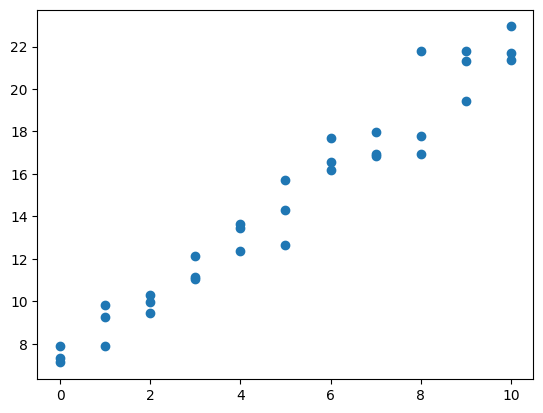

In [2]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = 33
#create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1*x + rng.standard_normal(n)
#visualize the data
plt.scatter(x = x, y = y)
plt.show()


Note that the relationship between our predictor and response is relatively strong because of the scale of the true slope value in comparison to the variability of $Y$ about its conditional mean ($\sigma^2=1$).

Now that we are able to simulate a dataset, we need to be able to extract the slope estimate relating $Y$ and $x$. To do so, we will use the `linear_model` submodule from `sklearn`.

In [8]:
# Read in linear_model submodule
from sklearn import linear_model

# Create a reg object
reg = linear_model.LinearRegression()

# Fit model between Y and x and print coefficients
reg.fit(x.reshape(-1,1), y)
print(reg.intercept_, reg.coef_)

7.259043801350283 [1.47450564]


Because of the strength of the simulated relationship between the response and predictor, we were able to fit the model relatively well; both coefficient estimates are fairly close to the true values.

We now want to repeat this process of simulating a dataset and fitting an SLR model 5,000 times to obtain a simulated sampling distribution for $\hat{\beta}_1$. To do so, we will construct a `for` loop that will repeat the above process. The 5,000 slope values will be capturing in a `numpy` array.

In [9]:
slopes = np.zeros(5000)

for i in range(5000):
    # get three 'values' of x at each integer from 0 to 10.
    x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
    n = 33
    # create the 'responses' modeled from the line plus a random deviation
    y = beta_0 + beta_1*x + rng.standard_normal(n)

    # Fitting model to simulated data
    reg.fit(x.reshape(-1,1), y)

    # Capturing estimated slope
    slopes[i] = reg.coef_[0]
